# BIG QUERY KISMINDA NE YAPTIK?


## Veriyi Buckets olusturarak Cloud Ortamına Aldık.

* Bu sekilde büyük boyutlu verisetlerini tabloya aktardık.

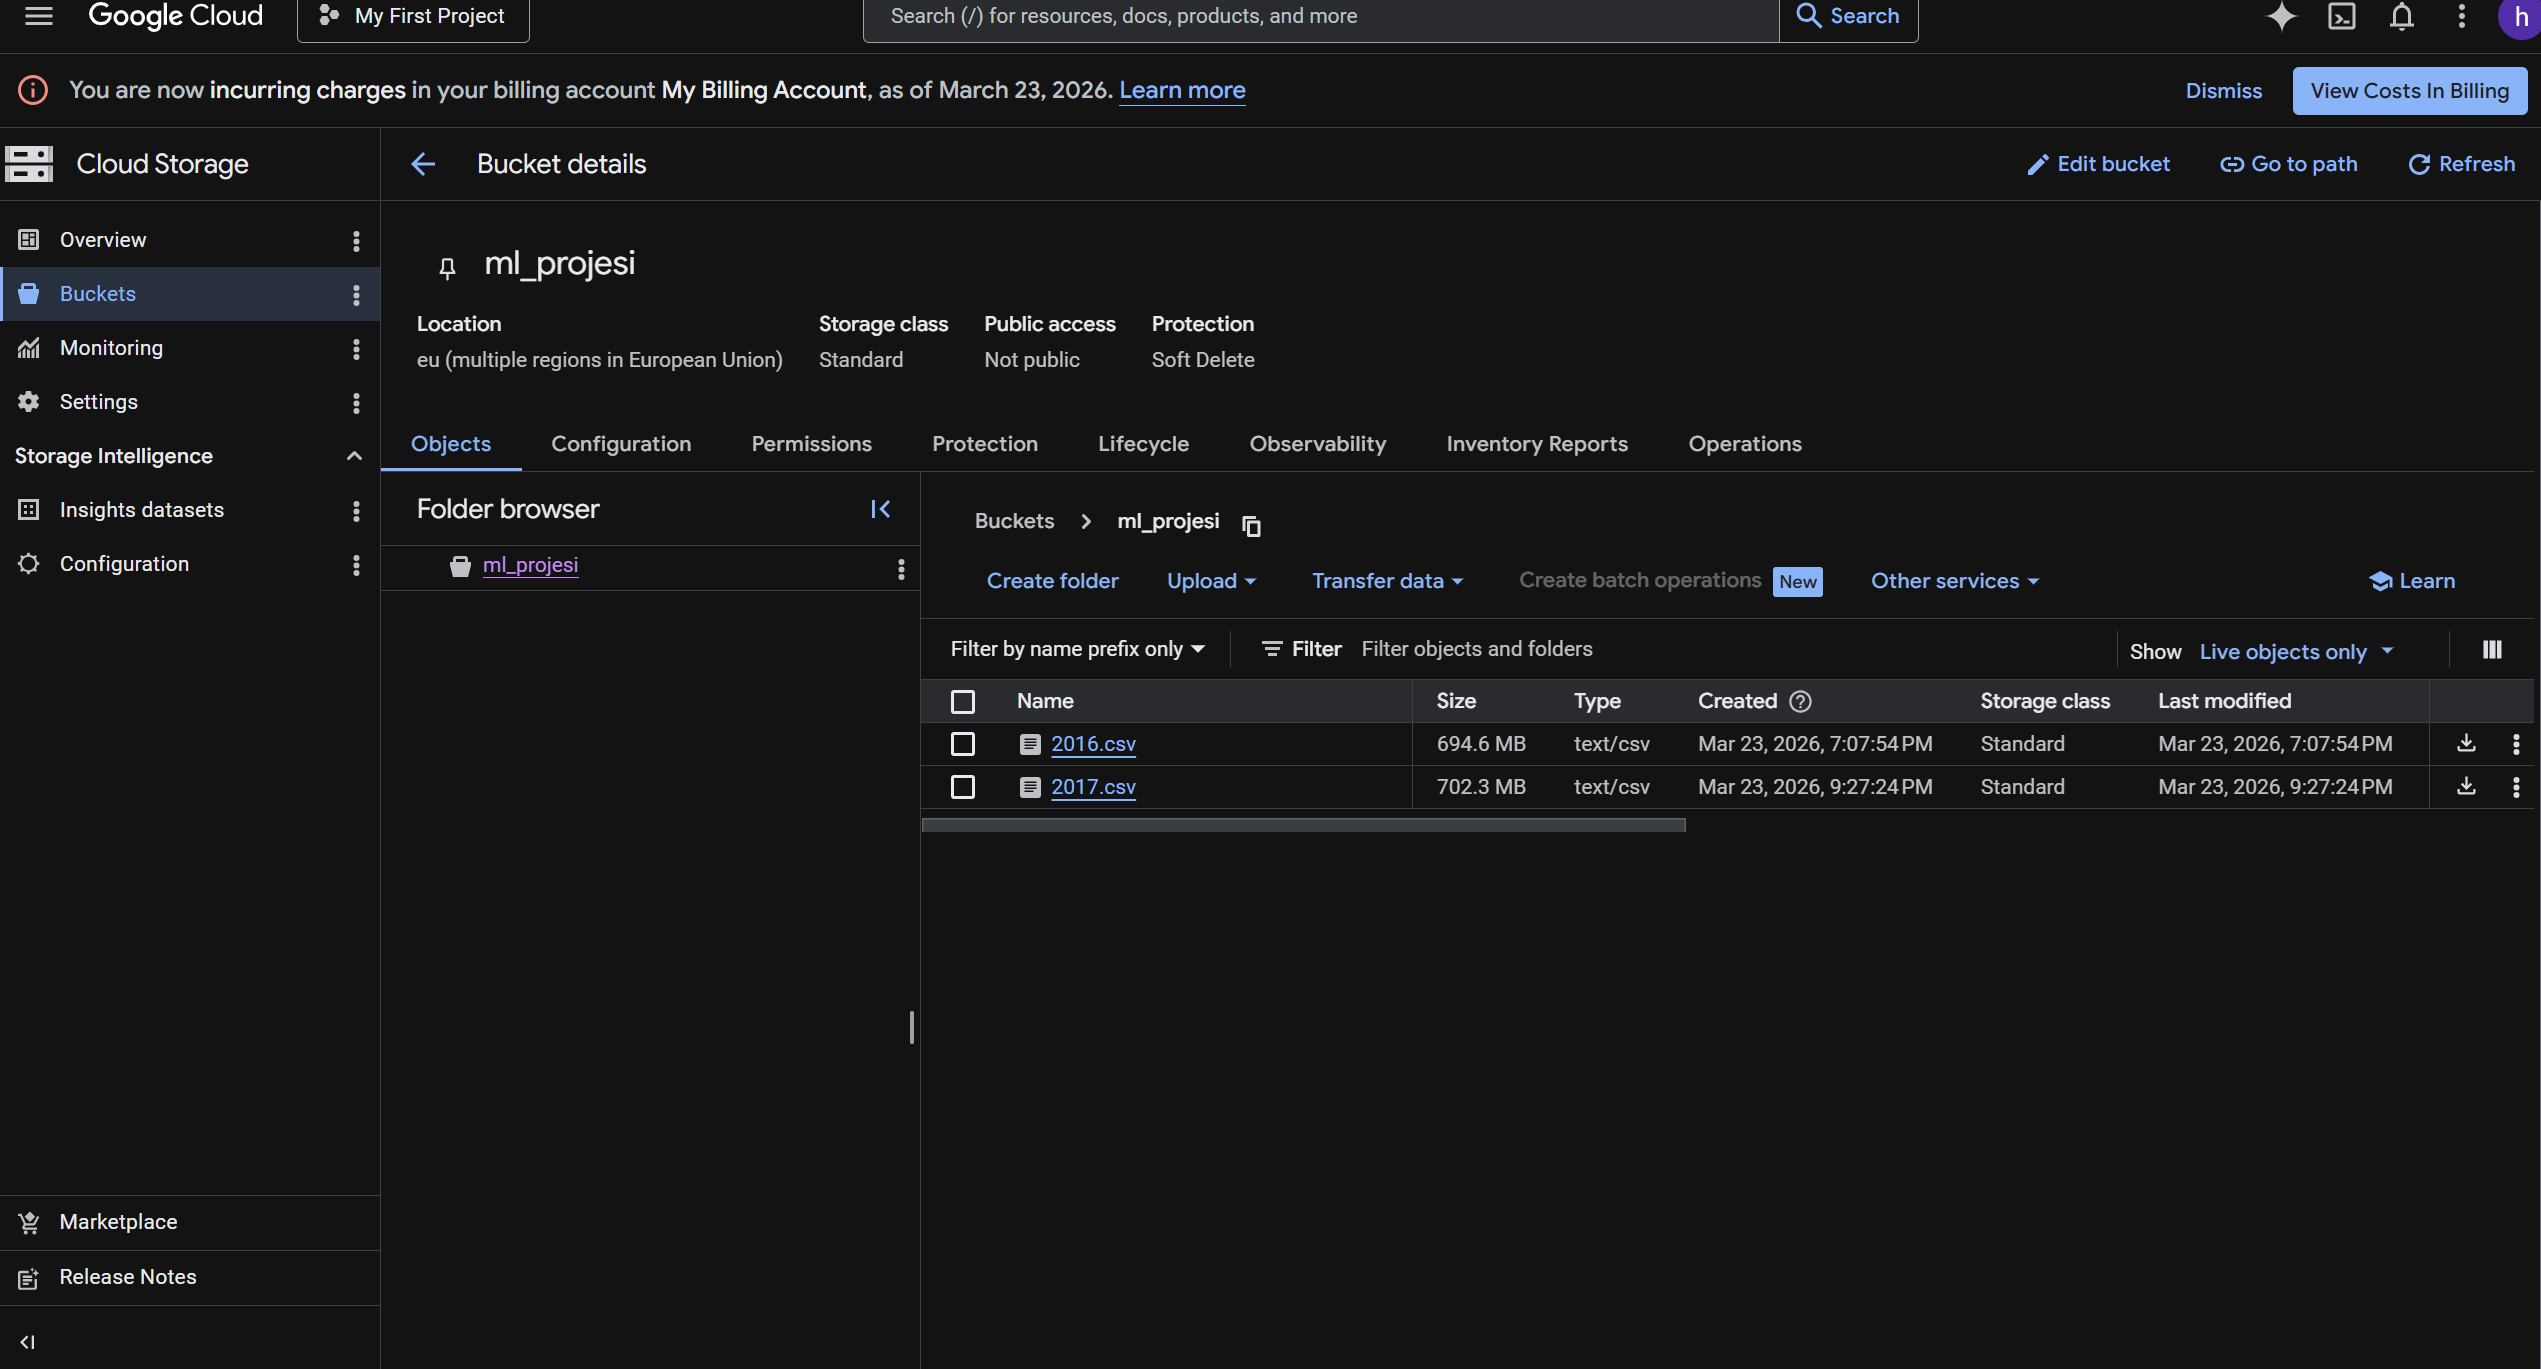

## Yetkilendirmeler Yapıldı


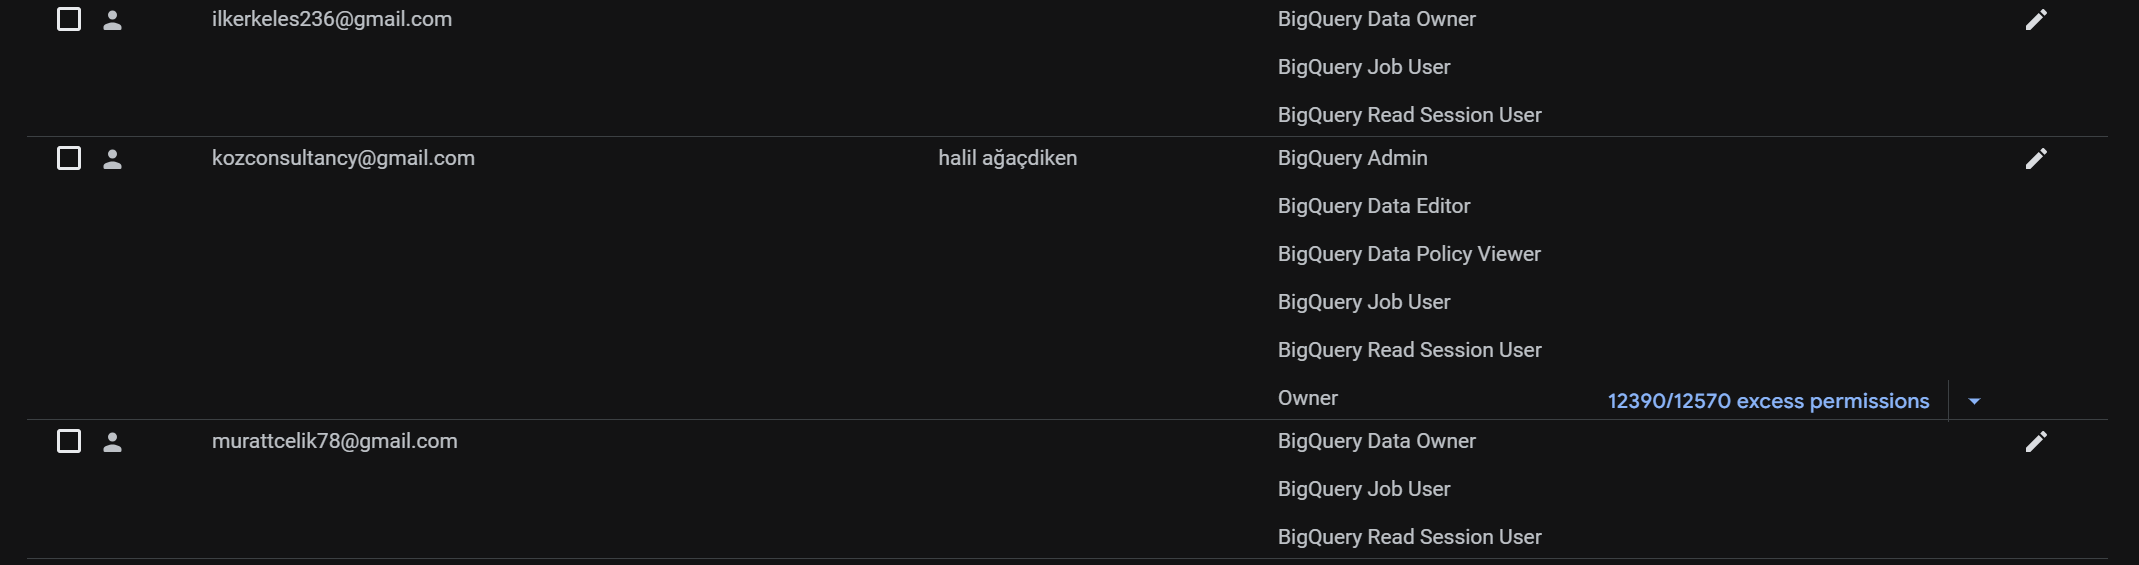

## SQL için Fonksiyonlar Yazıldı

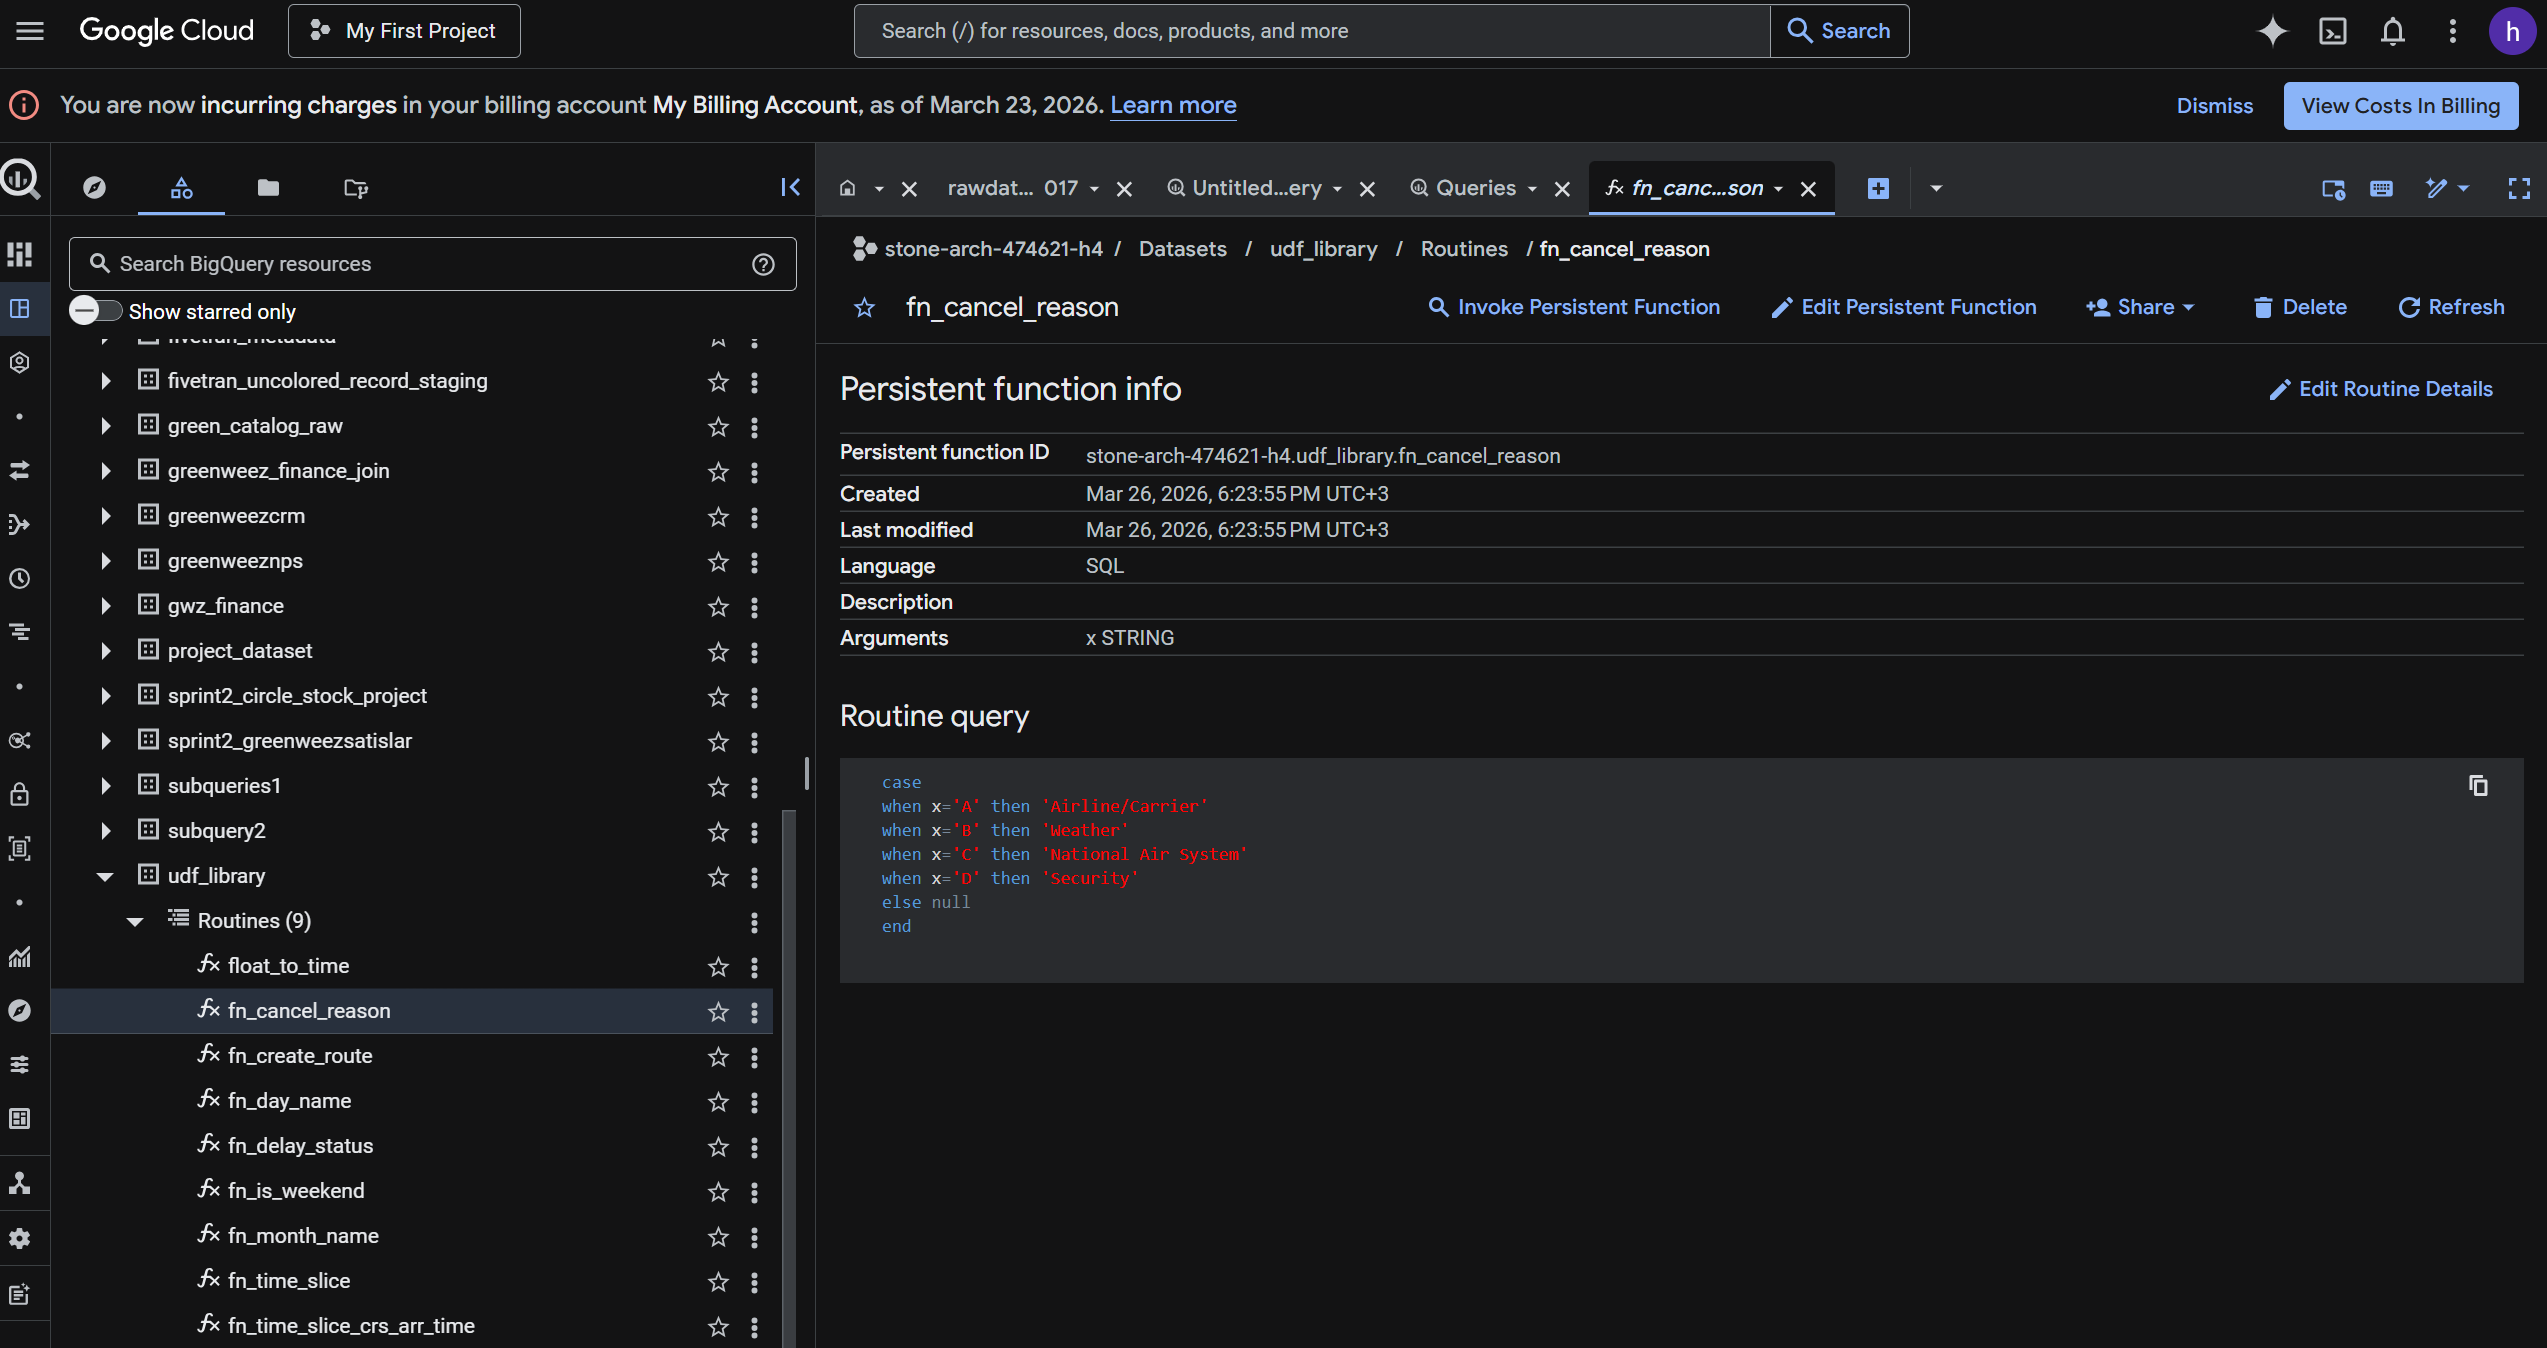



# ---



# **KAC DAKİKA ROTAR YAPAR TAHMİN MODELİ**


#1. Bağlantı - Kutuphaneler ve Veri Çekme (BigQuery)

* Kullanacağımız kutuphaneleri tanımlıyoruz.

In [ ]:
#sınıflandırma ıcın regresson ıcın
from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#sınıflandırma ıcın
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

* Baglantı tanımlıyoruz.

In [ ]:
import os
from google.colab import files
from google.cloud import bigquery

# 1. JSON Dosyasını Yükleme Paneli
print("Lütfen JSON anahtar dosyanızı seçin:")
uploaded = files.upload()

# 2. Dosya ismini otomatik al ve yolu tanımla
key_filename = list(uploaded.keys())[0]
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = os.path.abspath(key_filename)

# 3. Bağlantıyı Kur
project_id = "stone-arch-474621-h4"
client = bigquery.Client(project=project_id)

print(f"✅ Bağlantı Başarılı! {project_id} projesine erişildi.")

*   Veriyi cekiyoruz.




In [ ]:
from google.oauth2 import service_account

# 1. JSON dosyasını kullanarak doğrudan bir 'credentials' objesi oluşturuyoruz
# Not: 'key.json' dosyasının Colab'da yüklü olduğundan emin ol!
credentials = service_account.Credentials.from_service_account_file('key.json')

# 2. Veriyi çekmek için 'pandas_gbq' kullanıyoruz
# Bu kütüphane Storage API'yi kullanmaz, direkt standart sorgu atar.
print("Veri çekiliyor (Garanti Yöntem)...")

project_id = "stone-arch-474621-h4"
query_train = "SELECT * FROM `stone-arch-474621-h4.airplane_dataset.regresyon_2016_train_dataset_v3`"
df_train = pd.read_gbq(
    query_train,
    project_id=project_id,
    credentials=credentials,
    dialect='standard'
)
query_test = "SELECT * FROM `stone-arch-474621-h4.airplane_dataset.regresyon_2017_test_dataset_v3`"
df_test = pd.read_gbq(
    query_test,
    project_id=project_id,
    credentials=credentials,
    dialect='standard'
)

print(f"Başarılı! Toplam {len(df_train)} satır çekildi.")


## 2. Veri Hazırlama (Feature Engineering)

`is_train İşareti:` Eğitim ve test verilerini birleştirirken birbirine karışmasınlar diye bir "iz" bırakıyoruz.

In [ ]:
# A. Karışıklığı önlemek için işaret koyalım ve birleştirelim
# burada amac sutun ıcındeki degiskenlerden türedigi ıcın model birinde olup digerinde olmazsa boyut hatası vermesin diye
df_train['is_train'] = 1
df_test['is_train'] = 0
df_combined = pd.concat([df_train, df_test], axis=0)

"**One-Hot Encoding** yaparak 'Pazartesi, Salı' gibi isimleri 0 ve 1'lere dönüştürdük. drop_first=True kullanarak matematiksel bağımlılığı (multicollinearity) engelledik.

*   `One-Hot Encoding:` Bilgisayarlar "Pazartesi" veya "THY" kelimelerini anlayamaz. get_dummies ile bu kelimeleri 0 ve 1'lerden oluşan sütunlara çeviriyoruz

*   `Yeni Özellikler:` flight_period (Günün hangi saati) ve route (Rota) gibi BigQuery'de hazırladığımız yeni kolonları modele dahil ediyoruz.

In [ ]:
# Kategorik sütunları seçelim
# planned_dest_traffic_load sayısal buradan cıkarttım. bigquery de sutun olusturmustum
categorical_cols = ['carrier', 'ORIGIN', 'month_name', 'day_name', 'flight_period', 'route']

print(f" Encoding öncesi sütun sayısı: {df_combined.shape[1]}")

# Tüm kategorikleri 0-1 (Dummy) haline getirelim

df_final = pd.get_dummies(df_combined, columns=categorical_cols, drop_first=True)
# drop_first=True her sutundaki unique veriden 1 eksilerek tahmin yapmak ıcın yazıldı.
# mesela gun 7 adet -1 = 6 gunluk kombinasypn yaptı o gizledigi deger sıfır noktası (baseline) oluyor

 Encoding öncesi sütun sayısı: 11




---



* Verisetini etiket sonrası ayırıyoruz. Artık dimension hatası almayacapız.

In [ ]:
# Tekrar Train ve Test olarak ayıralım
train_v3 = df_final[df_final['is_train'] == 1].drop(['is_train'], axis=1)
test_v3 = df_final[df_final['is_train'] == 0].drop(['is_train'], axis=1)

In [ ]:
# E. Özellik (X) ve Hedef (y) ayırımı
X_train = train_v3.drop(['ARR_DELAY'], axis=1)
y_train = train_v3['ARR_DELAY']

X_test = test_v3.drop(['ARR_DELAY'], axis=1)
y_test = test_v3['ARR_DELAY']

print(f" Encoding sonrası TOPLAM sütun sayısı: {X_train.shape[1]}")


 Encoding sonrası TOPLAM sütun sayısı: 4683


## 3. Model - Regresyon (Gecikme Tahmini)

`HistGradientBoostingRegressor` kullandık çünkü bu model verideki eksik değerleri (null) otomatik yönetebilir ve çok hızlıdır.

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

# Not: max_iter değerini 100'den 200'e çıkararak modelin "öğrenme" kapasitesini artırdık
model = HistGradientBoostingRegressor(max_iter=200, random_state=42)
model.fit(X_train, y_train)
# Tahmin yap
y_pred = model.predict(X_test)


In [ ]:
# Metrikler
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- v3 MODEL PERFORMANSI ---")
print(f" R2 Skoru: {r2:.4f}")
print(f" Ortalama Hata (MAE): {mae:.2f} dakika")
print(f" RMSE: {rmse:.2f} dakika")


--- v3 MODEL PERFORMANSI ---
 R2 Skoru: 0.6700
 Ortalama Hata (MAE): 10.18 dakika
 RMSE: 27.21 dakika


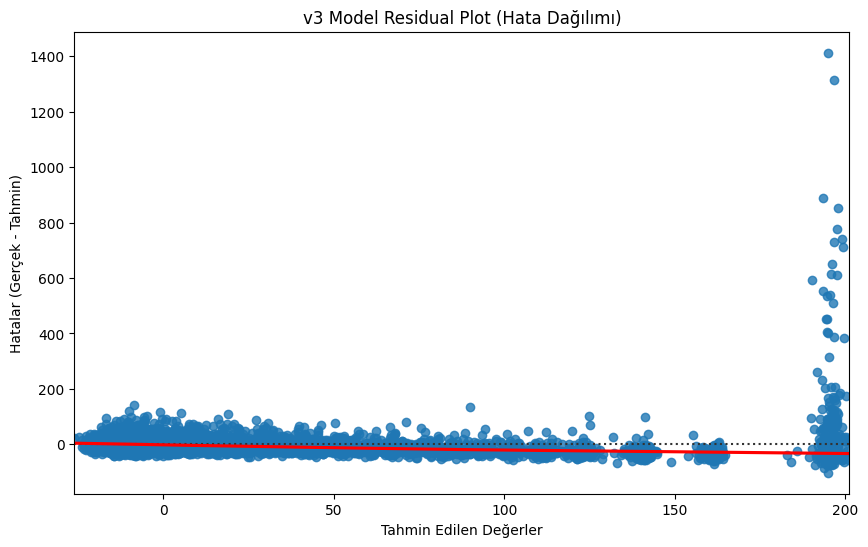

In [ ]:

# Grafiği çizdirelim (Artık Analizi)
plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred, y=y_test - y_pred, lowess=True, line_kws={'color': 'red'})
plt.title('v3 Model Residual Plot (Hata Dağılımı)')
plt.xlabel('Tahmin Edilen Değerler')
plt.ylabel('Hatalar (Gerçek - Tahmin)')
plt.show()





#---



# CANCELLED MODEL


## Veri Hazırlama

In [ ]:
from google.oauth2 import service_account

# 1. JSON dosyasını kullanarak doğrudan bir 'credentials' objesi oluşturuyoruz
# Not: 'key.json' dosyasının Colab'da yüklü olduğundan emin ol!
credentials = service_account.Credentials.from_service_account_file('key.json')

# 2. Veriyi çekmek için 'pandas_gbq' kullanıyoruz
# Bu kütüphane Storage API'yi kullanmaz, direkt standart sorgu atar.
print("Veri çekiliyo...")

project_id = "stone-arch-474621-h4"
query_train = "SELECT * FROM `stone-arch-474621-h4.airplane_dataset.cancelled_dataset_2016_train`"
df_train = pd.read_gbq(
    query_train,
    project_id=project_id,
    credentials=credentials,
    dialect='standard'
)
query_test = "SELECT * FROM `stone-arch-474621-h4.airplane_dataset.cancelled_dataset_2017_test`"
df_test = pd.read_gbq(
    query_test,
    project_id=project_id,
    credentials=credentials,
    dialect='standard'
)

print(f"Başarılı! Toplam {len(df_train)} satır çekildi.")

Veri çekiliyor (Garanti Yöntem)...


/tmp/ipykernel_23305/2438423630.py:13: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_train = pd.read_gbq(
/tmp/ipykernel_23305/2438423630.py:20: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_test = pd.read_gbq(


Başarılı! Toplam 99755 satır çekildi.


* Dimension hatası almamak için etiketleme yapıyoruz

In [ ]:
# 1. ETİKETLE VE BİRLEŞTİR
# Veri çekme kısmından hemen sonra burası başlar
df_train['is_train'] = 1
df_test['is_train'] = 0
df_combined = pd.concat([df_train, df_test], axis=0)

* One-Hot Encoding Ataması Yapıyorıuz

In [ ]:
# Sütun isimlerini küçük harfe sabitleyelim (BigQuery bazen büyük harf döndürebilir)
df_combined.columns = [col.lower() for col in df_combined.columns]

# 2. KATEGORİK SÜTUNLARI GÜNCELLE
# Yeni eklediğimiz 'flight_period' ve 'route' özelliklerini buraya dahil ettik
categorical_cols = ['carrier', 'origin', 'destination', 'month_name', 'day_name', 'flight_period', 'route']

# One-Hot Encoding (Aynı dili konuşmalarını sağlama)
df_final = pd.get_dummies(df_combined, columns=categorical_cols, drop_first=True)


* X ve Y tanımlaması yapıyoruz.

In [ ]:

# TEKRAR AYIR VE HEDEF DEĞİŞKENLERİ BELİRLE
X_train = df_final[df_final['is_train'] == 1].drop(['is_train', 'is_cancelled'], axis=1)
y_train = df_final[df_final['is_train'] == 1]['is_cancelled']

X_test = df_final[df_final['is_train'] == 0].drop(['is_train', 'is_cancelled'], axis=1)
y_test = df_final[df_final['is_train'] == 0]['is_cancelled']

print(f"--- Hazırlık Tamam ---")
print(f"Toplam Özellik Sayısı: {X_train.shape[1]}")

--- Hazırlık Tamam ---
Toplam Özellik Sayısı: 5000


## Model Egitimi

In [ ]:
# 4. RANDOM FOREST MODELİNİ KUR VE EĞİT
# class_weight='balanced' sayesinde azınlıktaki iptalleri daha ciddiye alacak
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
model_rf = RandomForestClassifier(
    n_estimators=150,      # Ağaç sayısını biraz artırdık (Daha fazla tecrübe)
    max_depth=15,          # Derinliği biraz artırdık (Yeni özellikleri iyice kavrasın)
    class_weight='balanced',
    random_state=42,
    n_jobs=-1              # İşlemciyi tam performans kullan (Hızlı eğitim için)
)
model_rf.fit(X_train, y_train)
# 5. TAHMİN VE PERFORMANS ANALİZİ
y_pred = model_rf.predict(X_test)


## Performans

In [ ]:
print("\n--- SINIFLANDIRMA PERFORMANSI (v2) ---")
print(classification_report(y_test, y_pred))


--- SINIFLANDIRMA PERFORMANSI (v2) ---
              precision    recall  f1-score   support

         0.0       0.99      0.82      0.89     24575
         1.0       0.02      0.31      0.04       352

    accuracy                           0.81     24927
   macro avg       0.51      0.56      0.47     24927
weighted avg       0.97      0.81      0.88     24927



### KARMAŞIKLIK MATRİSİ (CONFUSION MATRIX)

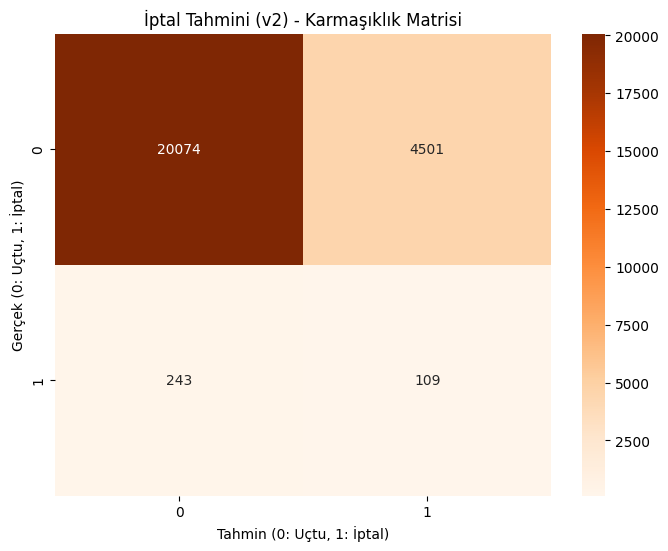

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('İptal Tahmini (v2) - Karmaşıklık Matrisi')
plt.xlabel('Tahmin (0: Uçtu, 1: İptal)')
plt.ylabel('Gerçek (0: Uçtu, 1: İptal)')
plt.show()



# ---



# SQL KODLARI


## 100K VE 25K ORNEKLEMELER

In [ ]:
from google.cloud import bigquery
from google.colab import auth
auth.authenticate_user()
# Proje ID'ni buraya tanımla
%env GOOGLE_CLOUD_PROJECT=stone-arch-474621-h4

env: GOOGLE_CLOUD_PROJECT=stone-arch-474621-h4


In [ ]:
%%bigquery

--EGİTİM SETİ %80 olarak 100.000 KULLANICI TABLE OLARAK AYIRACAĞIZ.
create or replace table  `stone-arch-474621-h4.airplane_dataset.sample100k_2016`
partition by FL_DATE as
with sub_query  as (


  select
  * except (`Unnamed: 27`) ,
  row_number() over (
    partition by  extract(month from FL_DATE)
    order by rand()--karısık sırala diyoruz.
  ) as row_number
  from `stone-arch-474621-h4.airplane_dataset.rawdata_2016`
)
--Hesap: 100.000 / 12 yaklasık  8.333 satır (ay başına).
select * except (row_number) from sub_query where row_number<=8333;


------------------------------------------------------------------------------------------
select * from `stone-arch-474621-h4.airplane_dataset.sample100k_2016`
;


--TEST SETİ %20 olarak 25.000 KULLANICI TABLE OLARAK AYIRACAĞIZ.

create or replace table  `stone-arch-474621-h4.airplane_dataset.sample25k_2017`
partition by FL_DATE as
with sub_query as (
  select
  * except (`Unnamed: 27`) ,
  row_number() over (
    partition by extract(month from FL_DATE)
    order by rand()
  )as row_number
  from `stone-arch-474621-h4.airplane_dataset.rawdata_2017`
)
--25000 / 12 yaklsık 2083 satır ay basına
select * except (row_number) from sub_query where row_number<=2083;

select * from `stone-arch-474621-h4.airplane_dataset.sample25k_2017`;

------------------------------------------------------------------------------------------

-- ML HEDEFİ ICIN  FONKSİYONLARI TANIMLAYAYIM VE ZENGİNLESTİRMEDE KULLANACAGIM:
-- Gecikme durumunu belirleyen fonksiyon
create or replace function `stone-arch-474621-h4.udf_library.fn_delay_status`(delay float64) as(
case
when delay <= 0 then 'on_time'
when delay > 0 then 'delayed'
else null
end);

-- İptal kodunu anlamlı metne çeviren fonksiyon
create or replace function `stone-arch-474621-h4.udf_library.fn_cancel_reason`(x string) as(
case
when x='A' then 'Airline/Carrier'
when x='B' then 'Weather'
when x='C' then 'National Air System'
when x='D' then 'Security'
else null
end
);
-- 1. Rota Oluşturma
create or replace function `stone-arch-474621-h4.udf_library.fn_create_route`(origin string, dest string) as (
  concat(origin, '-', dest)
);

-- 2. Ay İsmi
create or replace function `stone-arch-474621-h4.udf_library.fn_month_name`(d date) as (
  format_date('%B', d)
);

-- 3. Gün İsmi
create or replace function `stone-arch-474621-h4.udf_library.fn_day_name`(d date) as (
  format_date('%A', d)
);

-- 4. Hafta Sonu Kontrolü
create or replace function `stone-arch-474621-h4.udf_library.fn_is_weekend`(d date) as (
  if(extract(dayofweek from d) in (1, 7), 1, 0)
);

-- 5. Günün Dilimi
create or replace function `stone-arch-474621-h4.udf_library.fn_time_slice`(dep_time string) as (
  case
    when safe_cast(substr(lpad(dep_time, 4, '0'), 1, 2) as int64) between 6 and 11 then 'morning'
    when safe_cast(substr(lpad(dep_time, 4, '0'), 1, 2) as int64) between 12 and 17 then 'afternoon'
    when safe_cast(substr(lpad(dep_time, 4, '0'), 1, 2) as int64) between 18 and 23 then 'evening'
    else 'night'
  end
);

--DEP_TIME sütununu CAST(dep_time AS STRING) yaparak fonksiyona göndermeyi unutma. cunku
--strıng yazdımm

----------------------------------------------------------------------------------------------------------

-- CANCELLED Eğitim Seti İçin View (2016 - 100k Satır)
create or replace view `stone-arch-474621-h4.airplane_dataset.v_flights_2016_train_ready` as
select
  -- Hedef Değişken
  cancelled,

  -- Zaman Bazlı Özellikler (UDF Kütüphanenden)
  `stone-arch-474621-h4.udf_library.fn_month_name`(fl_date) as month_name,
  `stone-arch-474621-h4.udf_library.fn_day_name`(fl_date) as day_name,
  `stone-arch-474621-h4.udf_library.fn_is_weekend`(fl_date) as is_weekend,
  `stone-arch-474621-h4.udf_library.fn_time_slice`(cast(dep_time as string)) as flight_period,

  -- Rota ve Operasyonel Özellikler
  `stone-arch-474621-h4.udf_library.fn_create_route`(origin, dest) as route,
  distance,
  dep_delay,
  air_time,

  -- Analiz İçin Yardımcı Etiketler (eda atarken kulluanırız)
  `stone-arch-474621-h4.udf_library.fn_delay_status`(dep_delay) as delay_label,
  `stone-arch-474621-h4.udf_library.fn_cancel_reason`(cancellation_code) as cancel_reason_desc
from `stone-arch-474621-h4.airplane_dataset.sample100k_2016`;


-- CANCELLED Test Seti İçin View (2017 - 25k Satır)

create or replace view `stone-arch-474621-h4.airplane_dataset.v_flights_2017_test_ready` as
select
  cancelled,
  `stone-arch-474621-h4.udf_library.fn_month_name`(fl_date) as month_name,
  `stone-arch-474621-h4.udf_library.fn_day_name`(fl_date) as day_name,
  `stone-arch-474621-h4.udf_library.fn_is_weekend`(fl_date) as is_weekend,
  `stone-arch-474621-h4.udf_library.fn_time_slice`(cast(dep_time as string)) as flight_period,
  `stone-arch-474621-h4.udf_library.fn_create_route`(origin, dest) as route,
  distance,
  dep_delay,
  air_time,
  `stone-arch-474621-h4.udf_library.fn_delay_status`(dep_delay) as delay_label,
  `stone-arch-474621-h4.udf_library.fn_cancel_reason`(cancellation_code) as cancel_reason_desc
from `stone-arch-474621-h4.airplane_dataset.sample25k_2017`;----------------------------------------------------------------------------------------------------------

-- CANCELLED Eğitim Seti İçin View (2016 - 100k Satır)
create or replace view `stone-arch-474621-h4.airplane_dataset.v_flights_2016_train_ready` as
select
  -- Hedef Değişken
  cancelled,

  -- Zaman Bazlı Özellikler (UDF Kütüphanenden)
  `stone-arch-474621-h4.udf_library.fn_month_name`(fl_date) as month_name,
  `stone-arch-474621-h4.udf_library.fn_day_name`(fl_date) as day_name,
  `stone-arch-474621-h4.udf_library.fn_is_weekend`(fl_date) as is_weekend,
  `stone-arch-474621-h4.udf_library.fn_time_slice`(cast(dep_time as string)) as flight_period,

  -- Rota ve Operasyonel Özellikler
  `stone-arch-474621-h4.udf_library.fn_create_route`(origin, dest) as route,
  distance,
  dep_delay,
  air_time,

  -- Analiz İçin Yardımcı Etiketler (eda atarken kulluanırız)
  `stone-arch-474621-h4.udf_library.fn_delay_status`(dep_delay) as delay_label,
  `stone-arch-474621-h4.udf_library.fn_cancel_reason`(cancellation_code) as cancel_reason_desc
from `stone-arch-474621-h4.airplane_dataset.sample100k_2016`;


-- CANCELLED Test Seti İçin View (2017 - 25k Satır)

create or replace view `stone-arch-474621-h4.airplane_dataset.v_flights_2017_test_ready` as
select
  cancelled,
  `stone-arch-474621-h4.udf_library.fn_month_name`(fl_date) as month_name,
  `stone-arch-474621-h4.udf_library.fn_day_name`(fl_date) as day_name,
  `stone-arch-474621-h4.udf_library.fn_is_weekend`(fl_date) as is_weekend,
  `stone-arch-474621-h4.udf_library.fn_time_slice`(cast(dep_time as string)) as flight_period,
  `stone-arch-474621-h4.udf_library.fn_create_route`(origin, dest) as route,
  distance,
  dep_delay,
  air_time,
  `stone-arch-474621-h4.udf_library.fn_delay_status`(dep_delay) as delay_label,
  `stone-arch-474621-h4.udf_library.fn_cancel_reason`(cancellation_code) as cancel_reason_desc
from `stone-arch-474621-h4.airplane_dataset.sample25k_2017`;
----------------------------------------------------------------------------------------------------------

-- CANCELLED Eğitim Seti İçin View (2016 - 100k Satır)
create or replace view `stone-arch-474621-h4.airplane_dataset.v_flights_2016_train_ready` as
select
  -- Hedef Değişken
  cancelled,

  -- Zaman Bazlı Özellikler (UDF Kütüphanenden)
  `stone-arch-474621-h4.udf_library.fn_month_name`(fl_date) as month_name,
  `stone-arch-474621-h4.udf_library.fn_day_name`(fl_date) as day_name,
  `stone-arch-474621-h4.udf_library.fn_is_weekend`(fl_date) as is_weekend,
  `stone-arch-474621-h4.udf_library.fn_time_slice`(cast(dep_time as string)) as flight_period,

  -- Rota ve Operasyonel Özellikler
  `stone-arch-474621-h4.udf_library.fn_create_route`(origin, dest) as route,
  distance,
  dep_delay,
  air_time,

  -- Analiz İçin Yardımcı Etiketler (eda atarken kulluanırız)
  `stone-arch-474621-h4.udf_library.fn_delay_status`(dep_delay) as delay_label,
  `stone-arch-474621-h4.udf_library.fn_cancel_reason`(cancellation_code) as cancel_reason_desc
from `stone-arch-474621-h4.airplane_dataset.sample100k_2016`;


-- CANCELLED Test Seti İçin View (2017 - 25k Satır)

create or replace view `stone-arch-474621-h4.airplane_dataset.v_flights_2017_test_ready` as
select
  cancelled,
  `stone-arch-474621-h4.udf_library.fn_month_name`(fl_date) as month_name,
  `stone-arch-474621-h4.udf_library.fn_day_name`(fl_date) as day_name,
  `stone-arch-474621-h4.udf_library.fn_is_weekend`(fl_date) as is_weekend,
  `stone-arch-474621-h4.udf_library.fn_time_slice`(cast(dep_time as string)) as flight_period,
  `stone-arch-474621-h4.udf_library.fn_create_route`(origin, dest) as route,
  distance,
  dep_delay,
  air_time,
  `stone-arch-474621-h4.udf_library.fn_delay_status`(dep_delay) as delay_label,
  `stone-arch-474621-h4.udf_library.fn_cancel_reason`(cancellation_code) as cancel_reason_desc
from `stone-arch-474621-h4.airplane_dataset.sample25k_2017`;

-- CANCELLED Test Seti İçin View (2017 - 25k Satır)

create or replace view `stone-arch-474621-h4.airplane_dataset.v_flights_2017_test_ready` as
select
  cancelled,
  `stone-arch-474621-h4.udf_library.fn_month_name`(fl_date) as month_name,
  `stone-arch-474621-h4.udf_library.fn_day_name`(fl_date) as day_name,
  `stone-arch-474621-h4.udf_library.fn_is_weekend`(fl_date) as is_weekend,
  `stone-arch-474621-h4.udf_library.fn_time_slice`(cast(dep_time as string)) as flight_period,
  `stone-arch-474621-h4.udf_library.fn_create_route`(origin, dest) as route,
  distance,
  dep_delay,
  air_time,
  `stone-arch-474621-h4.udf_library.fn_delay_status`(dep_delay) as delay_label,
  `stone-arch-474621-h4.udf_library.fn_cancel_reason`(cancellation_code) as cancel_reason_desc
from `stone-arch-474621-h4.airplane_dataset.sample25k_2017`;
----------------------------------------------------------------------------------------------------------

-- ARR_DELAY REGRESYON Eğitim Seti İçin View (2016 - 100k Satır)
create or replace view `stone-arch-474621-h4.airplane_dataset.regresyon_2016_train_dataset` as
with percentiles as(
select
percentile_cont(ARR_DELAY, 0.25) over() as Q1,
percentile_cont(ARR_DELAY, 0.75) over() as Q3
from `stone-arch-474621-h4.airplane_dataset.sample100k_2016`
where cancelled = 0
and diverted = 0
and ARR_DELAY is not null

),
bounds as(
  select
  (Q1 - 3 * (Q3 - Q1)) as lower_bound,
  (Q3 + 3 * (Q3 - Q1)) as upper_bound
  from percentiles
  limit 1-- bir tane alt ve ust sınır al demek yoksa elindeki satır sayısı kadar üretir.
)



select
  -- Hedef Değişken
  t.ARR_DELAY,

  -- Zaman Bazlı Özellikler (UDF Kütüphanenden)
  `stone-arch-474621-h4.udf_library.fn_month_name`(fl_date) as month_name,
  `stone-arch-474621-h4.udf_library.fn_day_name`(fl_date) as day_name,
  `stone-arch-474621-h4.udf_library.fn_is_weekend`(fl_date) as is_weekend,
  `stone-arch-474621-h4.udf_library.fn_time_slice`(cast(dep_time as string)) as flight_period,

  -- Rota ve Operasyonel Özellikler
  `stone-arch-474621-h4.udf_library.fn_create_route`(origin, dest) as route,
  t.distance,
  t.dep_delay


from `stone-arch-474621-h4.airplane_dataset.sample100k_2016` as t,bounds-- tabloları virggul atarak  cross join ile  birlestirdik.
where t.cancelled = 0
  and t.diverted = 0
  and t.ARR_DELAY is not null

-- Sadece "normal" rötarları alıyoruz:
  and t.ARR_DELAY BETWEEN bounds.lower_bound AND bounds.upper_bound;

-- ARR_DELAY REGRESYON Test Seti İçin View (2017 - 25k Satır)

create or replace view `stone-arch-474621-h4.airplane_dataset.regresyon_2017_test_dataset` as
select
  ARR_DELAY,
  `stone-arch-474621-h4.udf_library.fn_month_name`(fl_date) as month_name,
  `stone-arch-474621-h4.udf_library.fn_day_name`(fl_date) as day_name,
  `stone-arch-474621-h4.udf_library.fn_is_weekend`(fl_date) as is_weekend,
  `stone-arch-474621-h4.udf_library.fn_time_slice`(cast(dep_time as string)) as flight_period,
  `stone-arch-474621-h4.udf_library.fn_create_route`(origin, dest) as route,
  distance,
  dep_delay

from `stone-arch-474621-h4.airplane_dataset.sample25k_2017`
where cancelled = 0
  and diverted = 0
  and ARR_DELAY is not null;

## CANCELLED TABLOSU

In [ ]:
%%bigquery

/*
DEP_DELAY, ARR_DELAY, AIR_TIME gibi sütunları sildik: Çünkü eğer bir uçuş iptal edildiyse, bu değerler zaten oluşmamıştır (veya NULL'dur). Bu verileri modele verirsen model "Eğer rötar NULL ise uçuş iptaldir" gibi çok basit ve anlamsız bir kural öğrenir. Buna Target Leakage (Hedef Sızıntısı) denir.

CRS_DEP_TIME (Planlanan Saat) bıraktık: İptaller genelde günün yoğun saatlerinde veya hava muhalefetinin arttığı saatlerde kümelenir.


*/

CREATE OR REPLACE VIEW `stone-arch-474621-h4.airplane_dataset.cancelled_dataset_2016_train` AS
SELECT
  -- HEDEF DEĞİŞKEN
  CAST(CANCELLED AS INT64) as is_cancelled,

  -- KATEGORİK ÖZELLİKLER (UDF Destekli)
  OP_CARRIER as carrier,
  ORIGIN as origin,
  DEST as destination,

  -- Senin UDF Fonksiyonların
  `stone-arch-474621-h4.udf_library.fn_month_name`(FL_DATE) as month_name,
  `stone-arch-474621-h4.udf_library.fn_day_name`(FL_DATE) as day_name,
  -- Planlanan saate göre günün dilimi (Morning, Afternoon vb.)
  `stone-arch-474621-h4.udf_library.fn_time_slice`(CAST(CRS_DEP_TIME AS STRING)) as flight_period,
  -- Rota birleşimi (Origin-Dest)
  `stone-arch-474621-h4.udf_library.fn_create_route`(ORIGIN, DEST) as route,

  -- SAYISAL ÖZELLİKLER
  DISTANCE as distance,
  CRS_DEP_TIME as planned_dep_time -- Modelin saat bazlı ince ayar yapabilmesi için ham hali

FROM `stone-arch-474621-h4.airplane_dataset.sample100k_2016`
WHERE DIVERTED = 0 -- Sadece net sonuçlara odaklanıyoruz
;
--TEST
----------------------------------------------------------------------------------------------------------------

CREATE OR REPLACE VIEW `stone-arch-474621-h4.airplane_dataset.cancelled_dataset_2017_test` AS
SELECT
  CAST(CANCELLED AS INT64) as is_cancelled,
  OP_CARRIER as carrier,
  ORIGIN as origin,
  DEST as destination,
  `stone-arch-474621-h4.udf_library.fn_month_name`(FL_DATE) as month_name,
  `stone-arch-474621-h4.udf_library.fn_day_name`(FL_DATE) as day_name,
  `stone-arch-474621-h4.udf_library.fn_time_slice`(CAST(CRS_DEP_TIME AS STRING)) as flight_period,
  `stone-arch-474621-h4.udf_library.fn_create_route`(ORIGIN, DEST) as route,
  DISTANCE as distance,
  CRS_DEP_TIME as planned_dep_time

FROM `stone-arch-474621-h4.airplane_dataset.sample25k_2017`
WHERE DIVERTED = 0


## REGRESYON TABLOSU

In [ ]:
%%bigquery

-- hangileri data leakage :  ucak ındıkten sonraki veriler :
-- AIR_TIME, ACTUAL_ELAPSED_TIME: Uçağın havada ne kadar kaldığı, ancak indikten sonra bilinir.
-- WHEELS_ON, TAXI_IN, ARR_TIME: Teker koyma ve körüğe yanaşma saatleri varış rötarının kendisidir zaten.
-- CARRIER_DELAY, WEATHER_DELAY, NAS_DELAY vb.: Bunlar gecikmenin sebepleridir ve uçak indikten sonra raporlanır.

--TRAIN VE TEST ICIN VERİSETİNİ YAZIYORUM.



CREATE OR REPLACE VIEW `stone-arch-474621-h4.airplane_dataset.regresyon_2016_train_dataset_v3` AS
WITH limits AS (
  -- Modelin kafasını karıştırmamak için uç değerleri (Outlier) %0.5'lik dilimle sınırlıyoruz
  SELECT
    APPROX_QUANTILES(ARR_DELAY, 1000)[OFFSET(5)] AS lower_limit,
    APPROX_QUANTILES(ARR_DELAY, 1000)[OFFSET(995)] AS upper_limit
  FROM `stone-arch-474621-h4.airplane_dataset.sample100k_2016`
  WHERE CANCELLED = 0 AND DIVERTED = 0 AND ARR_DELAY IS NOT NULL
)
SELECT
  t.ARR_DELAY,        -- Hedef değişken (Tahmin edilecek değer)
  t.DEP_DELAY,        -- En temel tahmin edici (Kalkış rötarı)
  t.DISTANCE,         -- Yol mesafesi
  t.OP_CARRIER as carrier, -- Havayolu şirketi etkisi
  t.ORIGIN,           -- Kalkış havaalanı karakteristiği

  -- ZAMAN ÖZELLİKLERİ (Mevsimsellik ve gün içi döngü)
  `stone-arch-474621-h4.udf_library.fn_month_name`(FL_DATE) as month_name,
  `stone-arch-474621-h4.udf_library.fn_day_name`(FL_DATE) as day_name,
  `stone-arch-474621-h4.udf_library.fn_time_slice`(cast(DEP_TIME as string)) as flight_period,

  -- ROTA ÖZELLİĞİ (Senin yöntemin: Origin-Dest birleşimi)
  `stone-arch-474621-h4.udf_library.fn_create_route`(ORIGIN, DEST) as route,

  -- TRAFİK YOĞUNLUĞU (Fıskiyeyi kapatacak olan gizli silah)
  -- Varış meydanına senin planlanan iniş saat diliminde kaç uçak daha inecek?
  COUNT(*) OVER(
    PARTITION BY t.DEST, t.FL_DATE,
    `stone-arch-474621-h4.udf_library.fn_time_slice_crs_arr_time`(cast(t.CRS_ARR_TIME as string))
  ) as planned_dest_traffic_load

FROM `stone-arch-474621-h4.airplane_dataset.sample100k_2016` as t, limits
WHERE t.CANCELLED = 0
  AND t.DIVERTED = 0
  AND t.ARR_DELAY IS NOT NULL
  -- Sadece bilimsel sınırların içindeki verileri modele öğretiyoruz
  AND t.ARR_DELAY BETWEEN limits.lower_limit AND limits.upper_limit;

---------------------------------------------------------------------------------------------------------------------------------------


  CREATE OR REPLACE VIEW `stone-arch-474621-h4.airplane_dataset.regresyon_2017_test_dataset_v3` AS
SELECT
  t.ARR_DELAY,        -- Gerçek sonuç (Başarıyı ölçmek için)
  t.DEP_DELAY,
  t.DISTANCE,
  t.OP_CARRIER as carrier,
  t.ORIGIN,

  -- Eğitim setiyle birebir aynı özellikler (Features)
  `stone-arch-474621-h4.udf_library.fn_month_name`(FL_DATE) as month_name,
  `stone-arch-474621-h4.udf_library.fn_day_name`(FL_DATE) as day_name,
  `stone-arch-474621-h4.udf_library.fn_time_slice`(cast(DEP_TIME as string)) as flight_period,
  `stone-arch-474621-h4.udf_library.fn_create_route`(ORIGIN, DEST) as route,

  -- Test setinin kendi içindeki (2017 trafiği) yoğunluk hesaplaması
  COUNT(*) OVER(
    PARTITION BY t.DEST, t.FL_DATE,
    `stone-arch-474621-h4.udf_library.fn_time_slice_crs_arr_time`(cast(t.CRS_ARR_TIME as string))
  ) as planned_dest_traffic_load

FROM `stone-arch-474621-h4.airplane_dataset.sample25k_2017` as t
WHERE t.CANCELLED = 0
  AND t.DIVERTED = 0
  AND t.ARR_DELAY IS NOT NULL;